In [1]:
import os, json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_jsonl(filepath):
    data = []

    with open(filepath, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip():
                data.append(json.loads(line))

    return data

def save_jsonl(dataset, filepath):
    with open(filepath, 'w', encoding='utf-8') as file:
        for d in dataset:
            json.dump(d, file, ensure_ascii=False)
            file.write('\n')

In [3]:
run_name = "ch10_train"

checkpoint_dir = Path("data") / "ch10"

In [4]:
#epoches, steps = [], []
#train_losses, val_losses = [], []
#learning_rates, created_at = [], []

#json_files = sorted(
#    checkpoint_dir.glob("checkpoint_*.json"),
#    key=lambda x: x.stat().st_ctime,
#    #key=lambda x: int(x.name.split("-")[1]),
#    reverse=False,
#)

dataset = []
jsonl_file = checkpoint_dir / "checkpoints.jsonl"
json_files = list(checkpoint_dir.glob("checkpoint_*.json"))

if jsonl_file.exists():
    dataset = read_jsonl(jsonl_file)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())
    #tags = f.name.replace("checkpoint_", "").replace(".json", "").split("-", 1)
    #epoch, step = int(tags[0]), int(tags[1])
    dataset.append(data)

dataset = sorted(
    dataset,
    key=lambda x: x['step'],
    reverse=False,
)

#df = pd.DataFrame.from_records(dataset, columns=columns)
df = pd.DataFrame.from_records(dataset)
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step'], keep='last')

dataset = df.to_dict(orient='records')
dataset = [{k: v for k, v in rec.items() if pd.notna(v)} for rec in dataset]

In [5]:
#df = pd.DataFrame({
#    "epoch": epoches,
#    "step": steps,
#    "train_loss": train_losses,
#    "val_loss": val_losses,
#    "learning_rate": learning_rates,
#    "created_at": created_at,
#})

save_jsonl(dataset, jsonl_file)

for f in json_files:
    os.remove(f)

steps = df['step'].apply(lambda x: x/1e3).to_list()
df['step'] = df['step'].apply(lambda x: f"{x:_}")

df.to_csv(checkpoint_dir / "training.tsv", index=False, sep='\t')

columns=["epoch", "step", "train_loss", "val_loss", "learning_rate", "created_at"]

In [6]:
#print(df.nsmallest(1, 'train_loss'))
#pd.concat((df.head(10), df.tail(10)))

df[columns].head(30)

,epoch,step,train_loss,val_loss,learning_rate,created_at
0,1,10_000,4.447711,4.520644,0.000018,2025-09-23T01:06:15%:z
1,1,20_000,3.487282,3.731411,0.000033,2025-09-23T01:32:50%:z
2,1,30_000,2.889537,3.274384,0.000048,2025-09-23T01:59:24%:z
3,1,40_000,2.484455,2.962372,0.000062,2025-09-23T02:25:58%:z
4,1,50_000,2.242485,2.810005,0.000077,2025-09-23T02:52:33%:z
5,1,60_000,2.063628,2.737664,0.000092,2025-09-23T03:19:07%:z
6,1,70_000,1.901898,2.705799,0.000107,2025-09-23T03:45:42%:z
7,1,80_000,1.792064,2.700313,0.000122,2025-09-23T04:12:17%:z
8,1,90_000,1.682963,2.695072,0.000137,2025-09-23T04:38:52%:z
9,1,100_000,1.580567,2.691442,0.000152,2025-09-23T05:05:26%:z


In [7]:
df[columns].tail(30)

,epoch,step,train_loss,val_loss,learning_rate,created_at
49,3,480_000,0.883504,2.854681,0.000271,2025-09-23T22:19:16%:z
50,3,490_000,0.891391,2.788355,0.000264,2025-09-23T22:45:53%:z
51,3,500_000,0.859747,2.918856,0.000256,2025-09-23T23:12:30%:z
52,3,510_000,0.847883,2.950415,0.000248,2025-09-23T23:39:09%:z
53,3,520_000,0.833078,2.912120,0.000238,2025-09-24T00:05:48%:z
54,3,530_000,0.836261,2.891829,0.000229,2025-09-24T00:32:27%:z
55,3,540_000,0.842214,2.849273,0.000218,2025-09-24T00:59:05%:z
56,3,550_000,0.805991,2.956306,0.000208,2025-09-24T01:25:45%:z
57,3,560_000,0.802010,2.950136,0.000197,2025-09-24T01:52:24%:z
58,3,566_805,0.804603,2.979278,0.000189,2025-09-24T02:11:00%:z


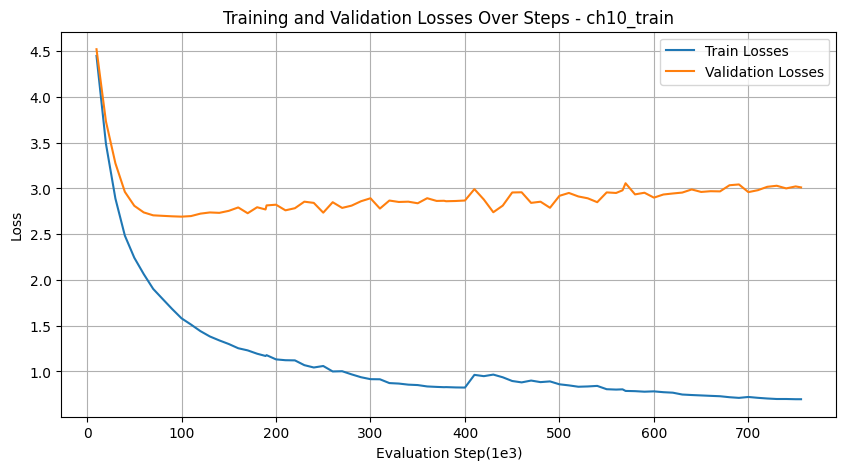

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(steps, df['train_loss'], label="Train Losses")
plt.plot(steps, df['val_loss'], label="Validation Losses")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")

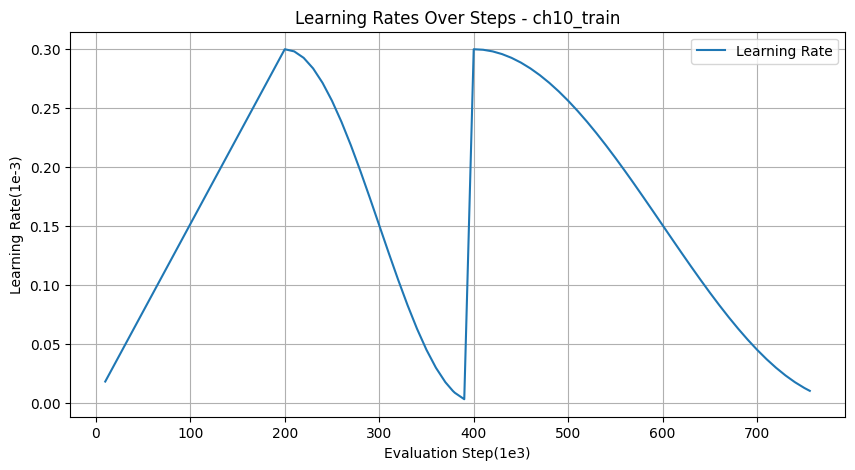

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(steps, df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(checkpoint_dir / "learning_rate.pdf")